In [135]:
import pandas as pd

In [136]:
uk_df = pd.read_csv('uk_financial_stats.csv', encoding="utf-8")
uk_df.head()



,Unnamed: 0,"Exchange Rates, National Currency Per U.S. Dollar, Period Average, Rate","Prices, Consumer Price Index, All items, Index","Prices, Consumer Price Index, All items, Percentage change, Corresponding period previous year, Percent"
0,Jan 1988,0.55,52.04,3.30
1,Feb 1988,0.57,52.15,3.11
2,Mar 1988,0.55,52.38,3.34
3,Apr 1988,0.53,53.04,3.42
4,May 1988,0.53,53.26,3.75


In [137]:
germany_df = pd.read_csv('germany_financial_stats.csv', encoding="utf-8")
germany_df.head()

,Unnamed: 0,"Exchange Rates, National Currency Per U.S. Dollar, Period Average, Rate","Prices, Consumer Price Index, All items, Index","Prices, Consumer Price Index, All items, Percentage change, Corresponding period previous year, Percent"
0,Jan 1988,1.65,63.50,0.89
1,Feb 1988,1.70,63.64,1.00
2,Mar 1988,1.68,63.64,1.00
3,Apr 1988,1.67,63.78,1.00
4,May 1988,1.69,63.92,1.22


In [138]:
uk_df.columns = (
    uk_df.columns.str.lower()  # Convert to lowercase
    .str.replace(r"[^a-zA-Z0-9]", "_", regex=True)  # Replace special characters with underscores
    .str.replace(r"__+", "_", regex=True)  # Remove double underscores
    .str.strip("_")  # Remove leading/trailing underscores
    + "_uk" # Ensure country can be identified
)
uk_df.head()

,unnamed_0_uk,exchange_rates_national_currency_per_u_s_dollar_period_average_rate_uk,prices_consumer_price_index_all_items_index_uk,prices_consumer_price_index_all_items_percentage_change_corresponding_period_previous_year_percent_uk
0,Jan 1988,0.55,52.04,3.30
1,Feb 1988,0.57,52.15,3.11
2,Mar 1988,0.55,52.38,3.34
3,Apr 1988,0.53,53.04,3.42
4,May 1988,0.53,53.26,3.75


In [139]:
germany_df.columns = (
    germany_df.columns.str.lower()  # Convert to lowercase
    .str.replace(r"[^a-zA-Z0-9]", "_", regex=True)  # Replace special characters with underscores
    .str.replace(r"__+", "_", regex=True)  # Remove double underscores
    .str.strip("_")  # Remove leading/trailing underscores
    + "_germany" # Ensure country can be identified
)
germany_df.head()

,unnamed_0_germany,exchange_rates_national_currency_per_u_s_dollar_period_average_rate_germany,prices_consumer_price_index_all_items_index_germany,prices_consumer_price_index_all_items_percentage_change_corresponding_period_previous_year_percent_germany
0,Jan 1988,1.65,63.50,0.89
1,Feb 1988,1.70,63.64,1.00
2,Mar 1988,1.68,63.64,1.00
3,Apr 1988,1.67,63.78,1.00
4,May 1988,1.69,63.92,1.22


In [140]:
# Rename 'Unnamed: 0' to 'Date' in both DataFrames
uk_df.rename(columns={"unnamed_0_uk": "date"}, inplace=True)
germany_df.rename(columns={"unnamed_0_germany": "date"}, inplace=True)

In [141]:
# Perform an inner merge on 'Date'
merged_df = pd.merge(uk_df, germany_df, on='date', how='inner')
merged_df.head()

,date,exchange_rates_national_currency_per_u_s_dollar_period_average_rate_uk,prices_consumer_price_index_all_items_index_uk,prices_consumer_price_index_all_items_percentage_change_corresponding_period_previous_year_percent_uk,exchange_rates_national_currency_per_u_s_dollar_period_average_rate_germany,prices_consumer_price_index_all_items_index_germany,prices_consumer_price_index_all_items_percentage_change_corresponding_period_previous_year_percent_germany
0,Jan 1988,0.55,52.04,3.30,1.65,63.50,0.89
1,Feb 1988,0.57,52.15,3.11,1.70,63.64,1.00
2,Mar 1988,0.55,52.38,3.34,1.68,63.64,1.00
3,Apr 1988,0.53,53.04,3.42,1.67,63.78,1.00
4,May 1988,0.53,53.26,3.75,1.69,63.92,1.22


In [142]:
# Define a dictionary for renaming the columns to simpler names
rename_dict = {
    "date": "date",
    "exchange_rates_national_currency_per_u_s_dollar_period_average_rate_uk": "nominal_exchange_rate_uk",
    "exchange_rates_national_currency_per_u_s_dollar_period_average_rate_germany": "nominal_exchange_rate_germany",
    "prices_consumer_price_index_all_items_index_uk": "cpi_uk",
    "prices_consumer_price_index_all_items_index_germany": "cpi_germany",
    "prices_consumer_price_index_all_items_percentage_change_corresponding_period_previous_year_percent_germany": "cpi_percentage_change_germany",
    "prices_consumer_price_index_all_items_percentage_change_corresponding_period_previous_year_percent_uk": "cpi_percentage_change_uk"
}

# Apply renaming to the DataFrame
merged_df.rename(columns=rename_dict, inplace=True)

In [143]:
merged_df.head()

,date,nominal_exchange_rate_uk,cpi_uk,cpi_percentage_change_uk,nominal_exchange_rate_germany,cpi_germany,cpi_percentage_change_germany
0,Jan 1988,0.55,52.04,3.30,1.65,63.50,0.89
1,Feb 1988,0.57,52.15,3.11,1.70,63.64,1.00
2,Mar 1988,0.55,52.38,3.34,1.68,63.64,1.00
3,Apr 1988,0.53,53.04,3.42,1.67,63.78,1.00
4,May 1988,0.53,53.26,3.75,1.69,63.92,1.22


<Figure size 1000x600 with 0 Axes>

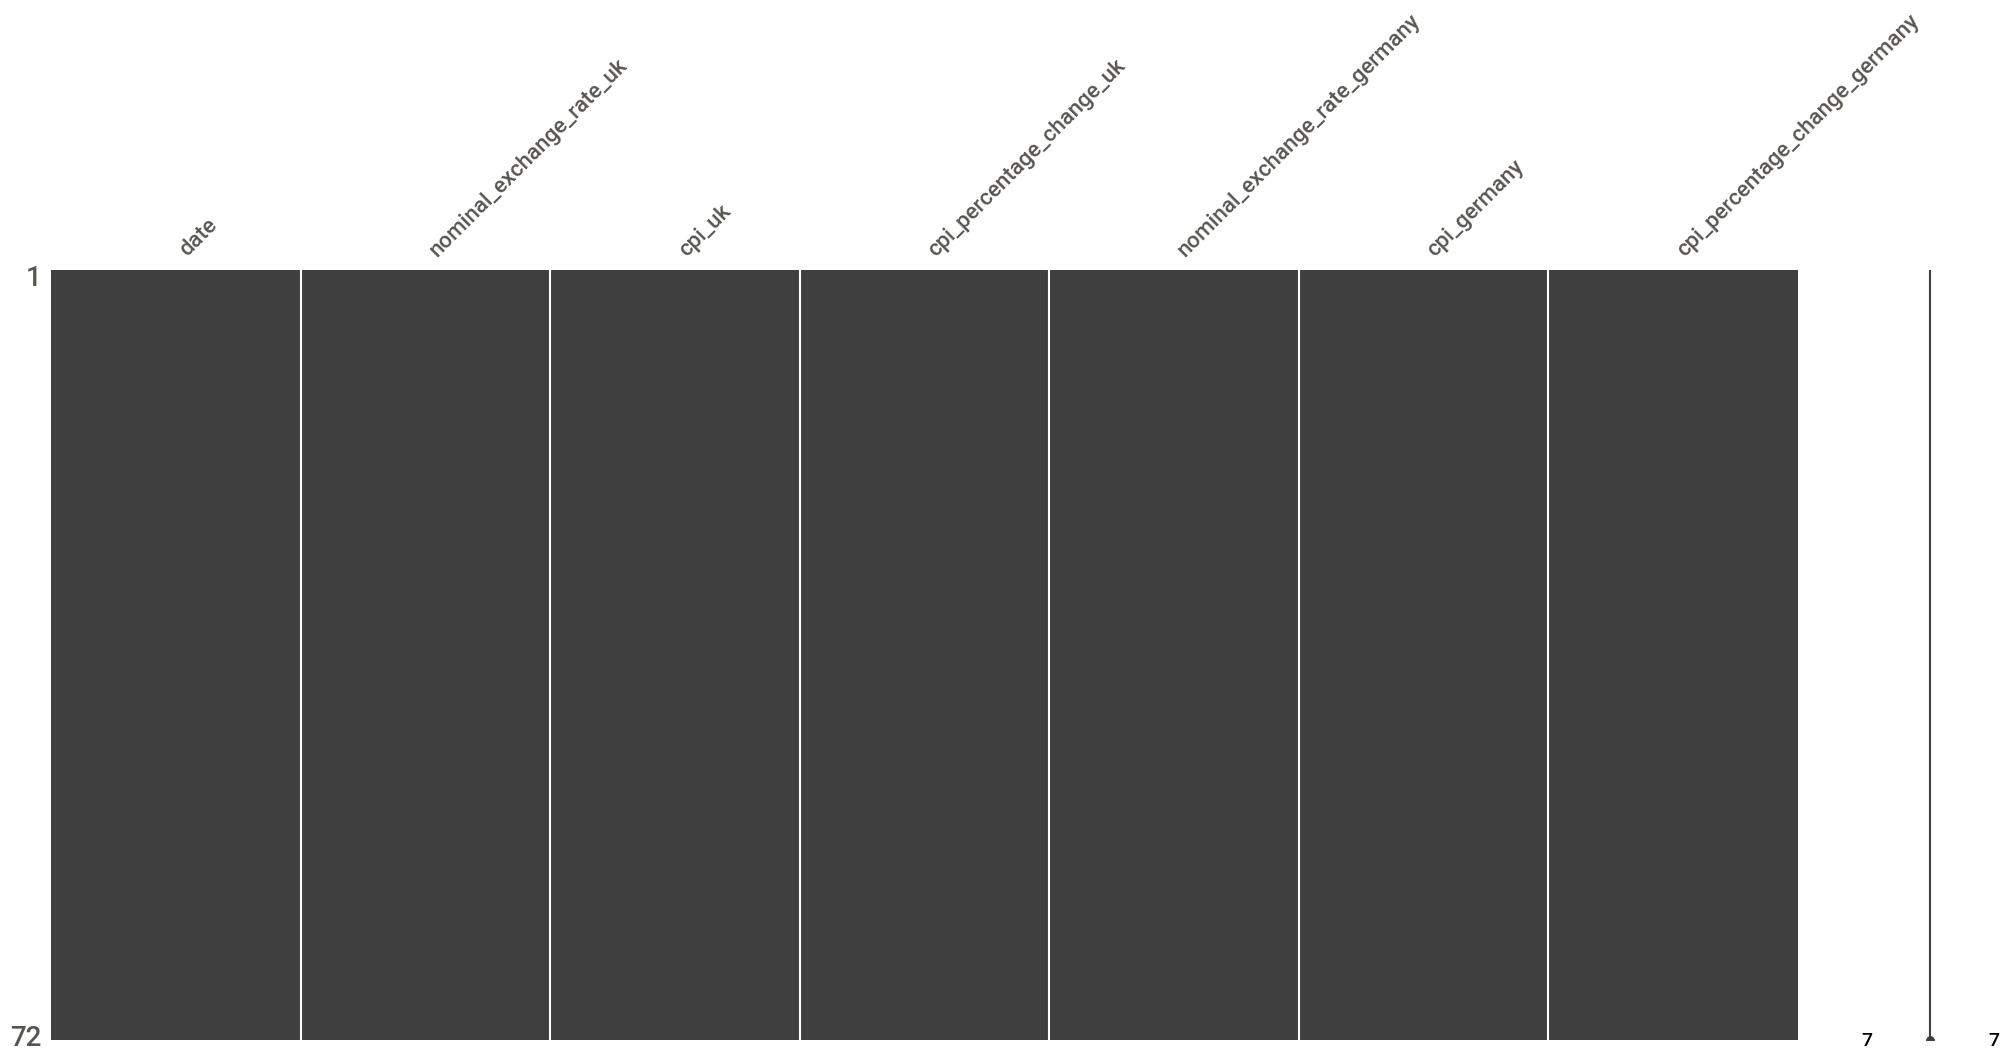

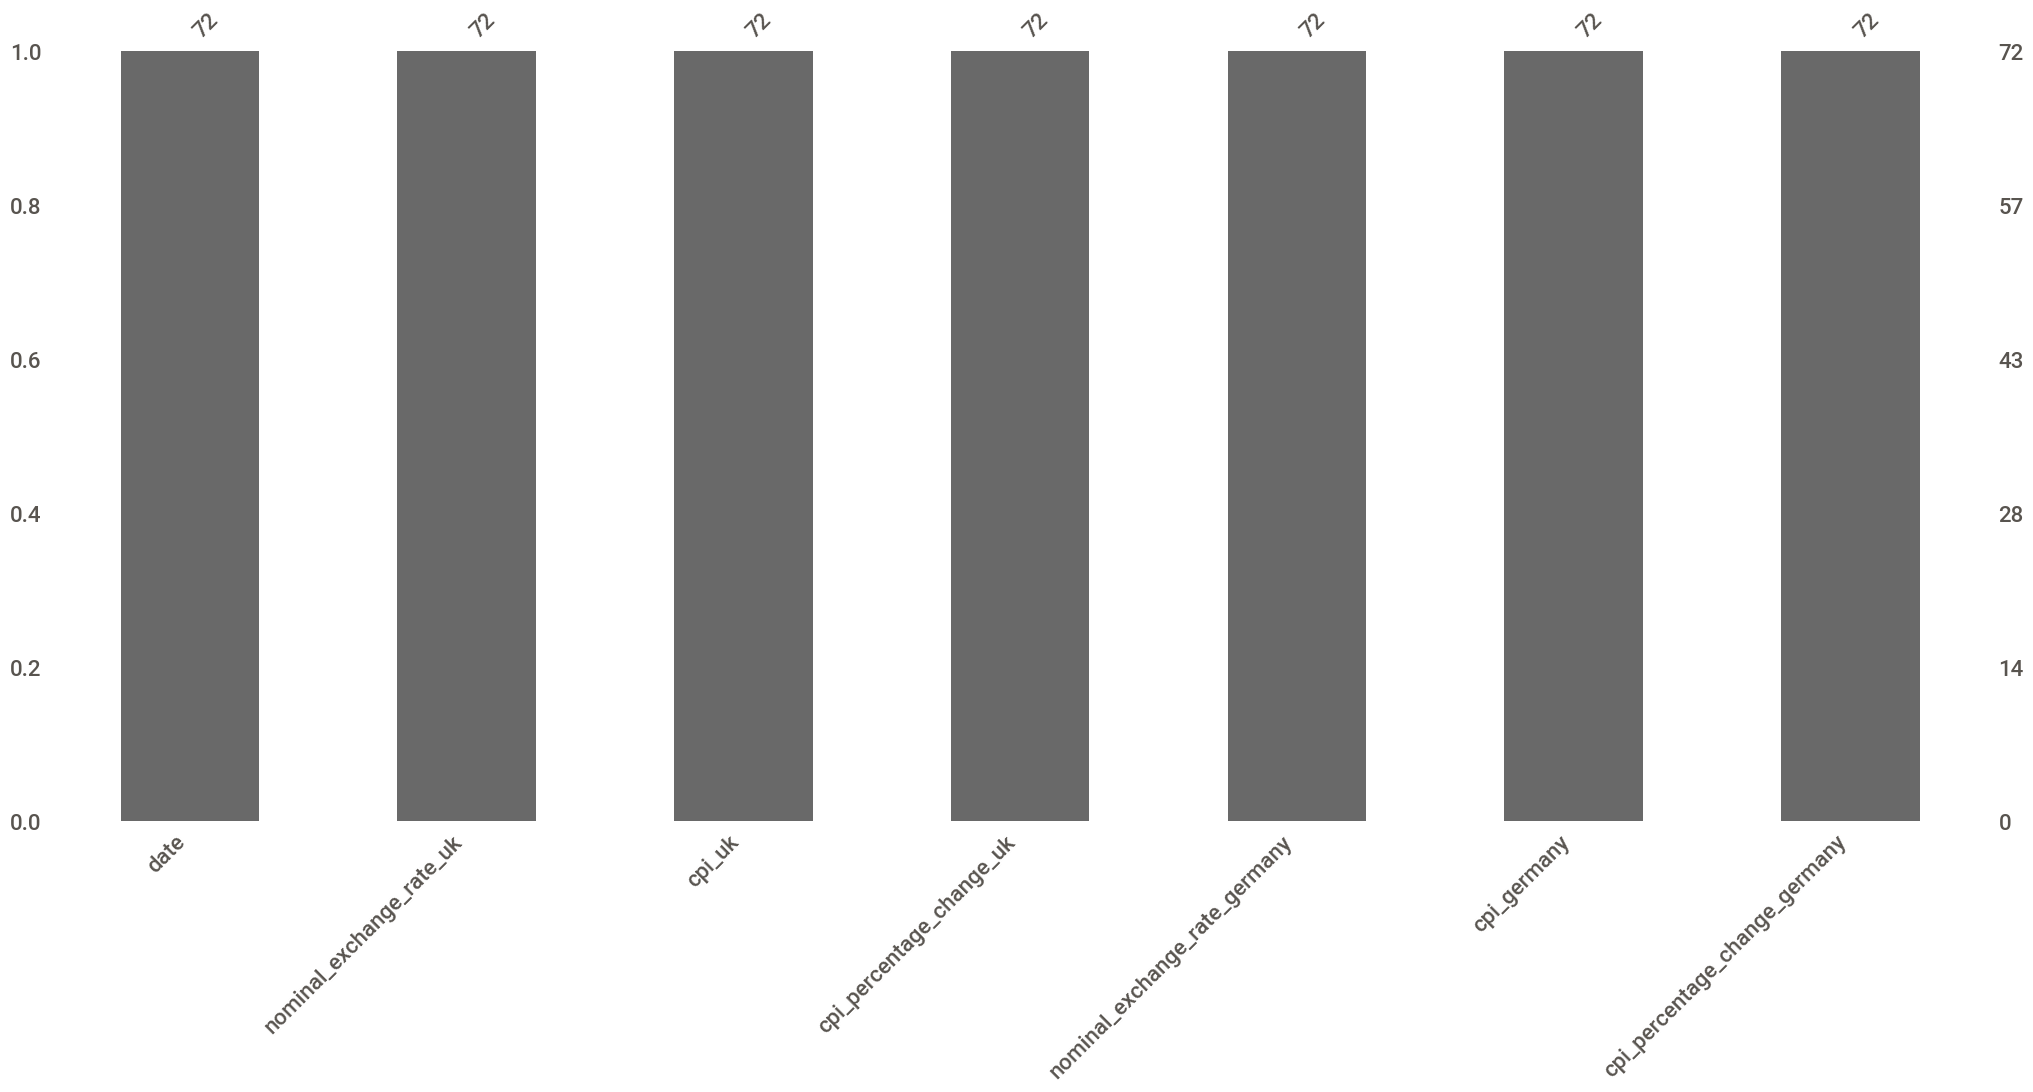

In [144]:
import missingno as msno
import sweetviz as sv
import matplotlib.pyplot as plt

# Generate missingness visualizations using missingno
plt.figure(figsize=(10, 6))
msno.matrix(merged_df)
plt.show()

plt.figure(figsize=(10, 6))
msno.bar(merged_df)
plt.show()


In [145]:
# Generate a Sweetviz report
report = sv.analyze(merged_df)
report.show_html("sweetviz_report.html")

#no missing values!

                                             |          | [  0%]   00:00 -> (? left)

Report sweetviz_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [146]:
# Show all rows and columns without truncation
pd.set_option("display.max_rows", None)  # Show all rows
pd.set_option("display.max_columns", None)  # Show all columns
pd.set_option("display.width", None)  # Expand width to fit the screen
pd.set_option("display.max_colwidth", None)  # Show full content of each cell

C:\Users\Hing\AppData\Local\Temp\ipykernel_17968\956116915.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  merged_df['date'] = pd.to_datetime(merged_df['date'])


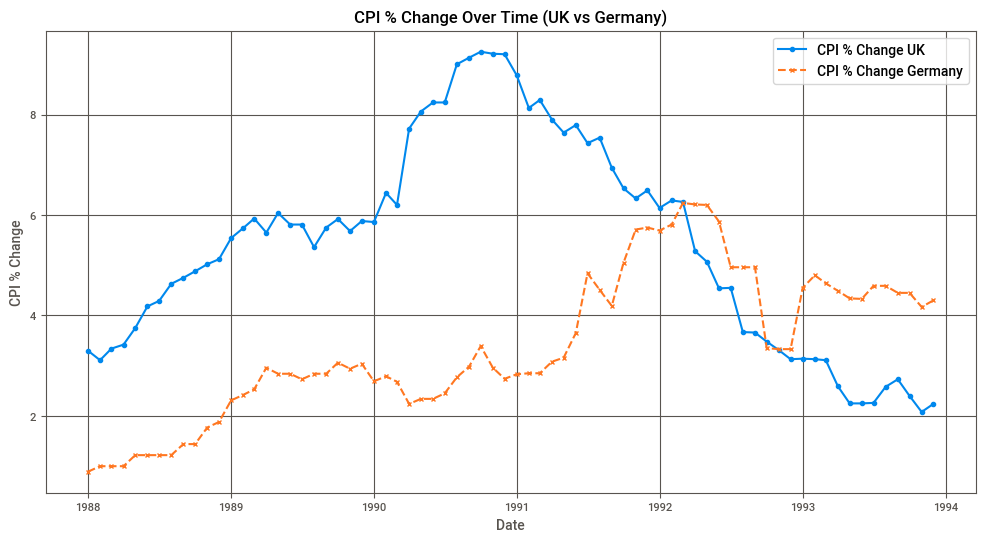

In [147]:
merged_df['date'] = pd.to_datetime(merged_df['date'])

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(merged_df['date'], merged_df['cpi_percentage_change_uk'], label='CPI % Change UK', linestyle='-', marker='o')
plt.plot(merged_df['date'], merged_df['cpi_percentage_change_germany'], label='CPI % Change Germany', linestyle='--', marker='x')

# Customize plot
plt.xlabel('Date')
plt.ylabel('CPI % Change')
plt.title('CPI % Change Over Time (UK vs Germany)')
plt.legend()
plt.grid(True)
plt.show()
